In [8]:
!pwd

/home/kataoka/TC_stabilizer_test/TEE/hexagonal123/v2/narrow/0.7-0.9


In [12]:
import numpy as np
import glob
import re

files = glob.glob("Lx_*_Nd_*_NT_*_px_0.0_MPI_hexagonal1234.npz")

Ls = []
Nds = []
NTs = []
pg_list = []

combined = {key: [] for key in [
    'TEE1_ave','TEE1_err','TEE1_var',
    'TEE2_ave','TEE2_err','TEE2_var',
    'TEE3_ave','TEE3_err','TEE3_var',
    'TEE4_ave','TEE4_err','TEE4_var',
]}

for filename in files:
    match_L = re.search(r"Lx_(\d+)_", filename)
    match_Nd = re.search(r"Nd_(\d+)_", filename)
    match_NT = re.search(r"NT_(\d+)_", filename)
    if not (match_L and match_Nd and match_NT):
        continue
    Lx = int(match_L.group(1))
    Nd = int(match_Nd.group(1))
    NT = int(match_NT.group(1))

    Ls.append(Lx)
    Nds.append(Nd)
    NTs.append(NT)

    data = np.load(filename)
    pg_list.append(data['pg'])

    for key in combined.keys():
        combined[key].append(data[key])

for key in combined:
    combined[key] = np.array(combined[key])

pg_all = np.array(pg_list)

# 昇順ソート
sort_idx = np.argsort(Ls)
Ls = np.array(Ls)[sort_idx]
Nds = np.array(Nds)[sort_idx]
NTs = np.array(NTs)[sort_idx]
pg_all = pg_all[sort_idx]
for key in combined:
    combined[key] = combined[key][sort_idx]

# 保存
np.savez("TEE_all_Lx.npz", Ls=Ls, Nds=Nds, NTs=NTs, pg=pg_all, **combined)


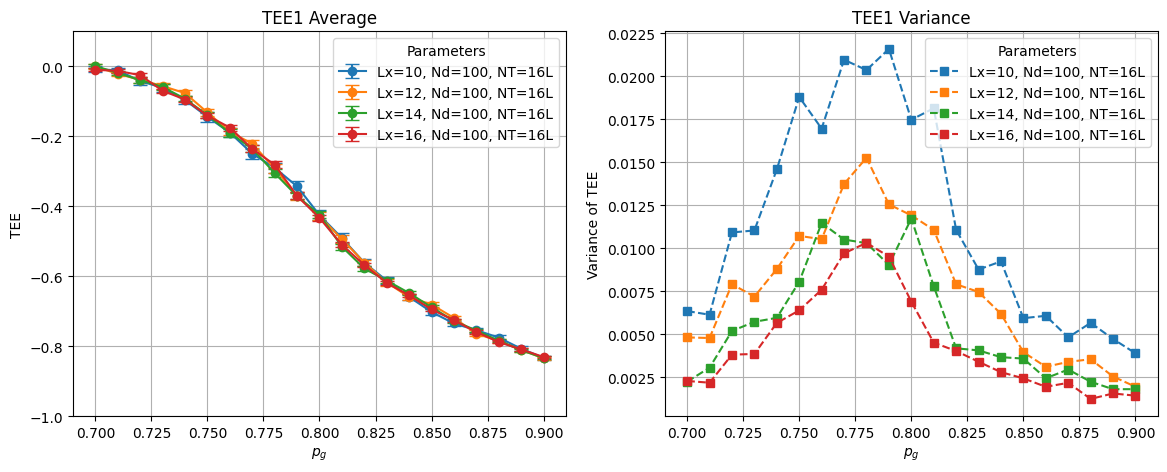

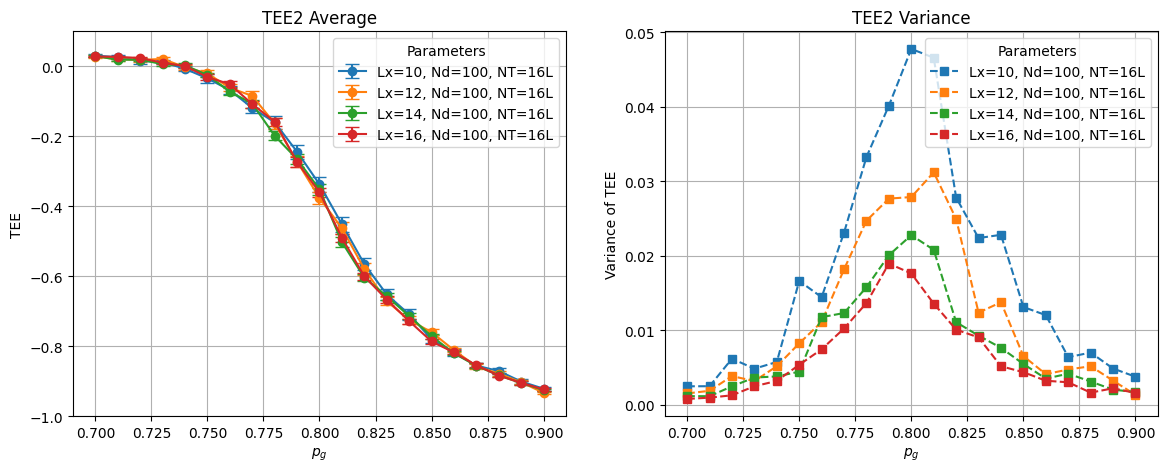

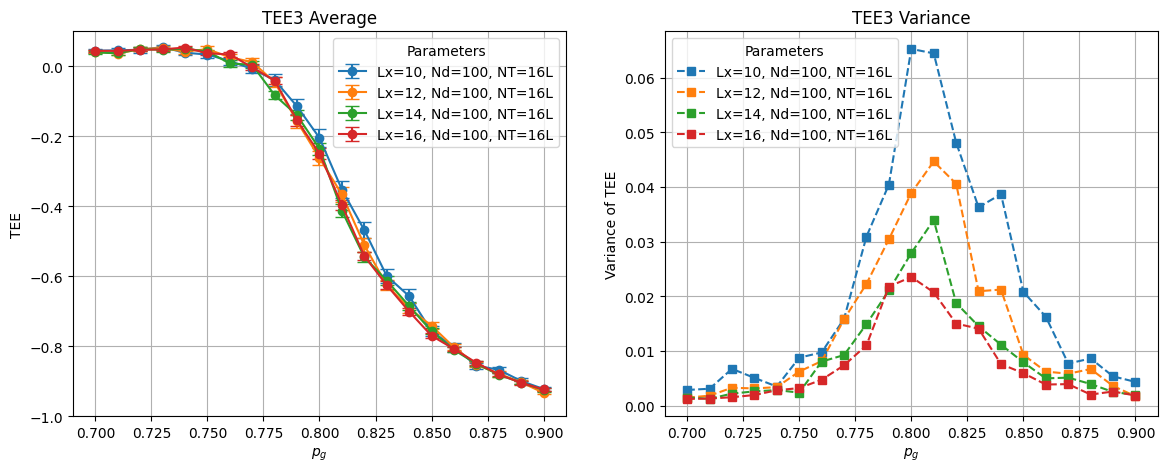

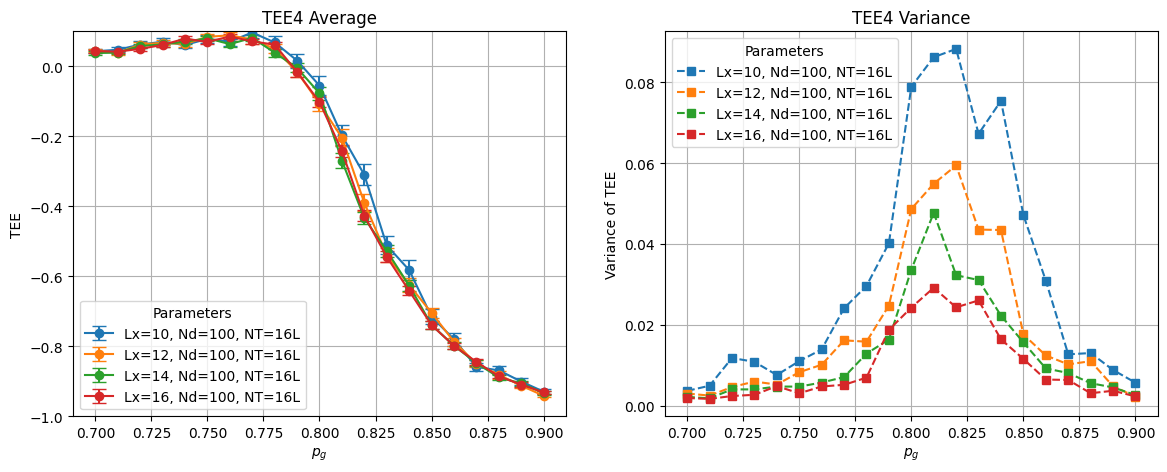

In [13]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("TEE_all_Lx.npz")

Ls = data['Ls']
Nds = data['Nds']
NTs = data['NTs']
pg = data['pg']

keys_ave = ['TEE1_ave','TEE2_ave','TEE3_ave','TEE4_ave']
keys_err = ['TEE1_err','TEE2_err','TEE3_err','TEE4_err']
keys_var = ['TEE1_var','TEE2_var','TEE3_var','TEE4_var']

num_regions = 4

for i_region in range(num_regions):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    region_name = f"TEE{i_region+1}"

    # 平均＋誤差
    for i_L, Lx in enumerate(Ls):
        label = f"Lx={Lx}, Nd={Nds[i_L]}, NT={NTs[i_L]//(3*Lx*Lx)}L"
        ax[0].errorbar(pg[i_L], data[keys_ave[i_region]][i_L],
                      yerr=data[keys_err[i_region]][i_L],
                      fmt='o-', capsize=5,
                      label=label)
    ax[0].set_xlabel('$p_g$')
    ax[0].set_ylabel('TEE')
    ax[0].set_ylim(-1, 0.1)
    ax[0].set_title(region_name + " Average")
    ax[0].grid(True)
    ax[0].legend(title="Parameters")

    # 分散
    for i_L, Lx in enumerate(Ls):
        label = f"Lx={Lx}, Nd={Nds[i_L]}, NT={NTs[i_L]//(3*Lx*Lx)}L"
        ax[1].plot(pg[i_L], data[keys_var[i_region]][i_L],
                   's--',
                   label=label)
    ax[1].set_xlabel('$p_g$')
    ax[1].set_ylabel('Variance of TEE')
    ax[1].set_title(region_name + " Variance")
    ax[1].grid(True)
    ax[1].legend(title="Parameters")


    plt.savefig(f"TEE_Lx_all_results_TEE{i_region+1}.png", dpi=300, bbox_inches='tight')
    plt.show()



In [21]:
import numpy as np

data = np.load("test.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['Ls', 'pg', 'TEE1_ave', 'TEE1_err', 'TEE1_var', 'TEE2_ave', 'TEE2_err', 'TEE2_var', 'TEE3_ave', 'TEE3_err', 'TEE3_var', 'TEE4_ave', 'TEE4_err', 'TEE4_var']


In [22]:
import numpy as np

data = np.load("test.npz")
print(data['Ls'])
print(data['pg'])
print(data['TEE1_ave'])
print(data['TEE1_err'])
print(data['TEE1_var'])
print(data['TEE2_ave'])
print(data['TEE2_err'])
print(data['TEE2_var'])
print(data['TEE3_ave'])
print(data['TEE3_err'])
print(data['TEE3_var'])
print(data['TEE4_ave'])
print(data['TEE4_err'])
print(data['TEE4_var'])
data.close()

[12 12 16 20]
[[0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9 ]
 [0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9 ]
 [0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9 ]
 [0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9 ]]
[[-0.100625   -0.03770833 -0.11673611 -0.16194444 -0.310625   -0.42465278
  -0.55388889 -0.65027778 -0.70527778 -0.78659722 -0.83618056]
 [-0.00298611 -0.03805556 -0.07715278 -0.15902778 -0.324375   -0.42819444
  -0.57118056 -0.65194444 -0.72854167 -0.77604167 -0.83513889]
 [-0.00800781 -0.03457031 -0.11230469 -0.16425781 -0.27734375 -0.43910156
  -0.56410156 -0.66777344 -0.72585937 -0.78011719 -0.83847656]
 [-0.0033     -0.035      -0.09815    -0.179675   -0.2974     -0.437775
  -0.56495    -0.64785    -0.720625   -0.781475   -0.837525  ]]
[[0.00680163 0.00803469 0.01035532 0.01126649 0.01172953 0.01120861
  0.00895443 0.00941552 0.00636723 0.00598268 0.00410791]
 [0.00540106 0.00806568 0.0077449  0.01123298 0.01198768 0.00942932
  0.00812339